# Kalshi & Weather Event Research Lab
This notebook provides an environment to backtest binary event contracts (Yes/No) specifically focused on Weather Arbitrage and Kalshi-style markets. 

### Why this is different from Stock/Crypto backtesting:
1. **Fixed Payouts**: Binary contracts settle at exactly $1.00 (Yes) or $0.00 (No).
2. **Event Driven**: We aren't trading continuous price trends, but discrete event outcomes (e.g., 'Will it be > 80°F?').
3. **Cost as Price**: The 'Price' of a contract (e.g., 60¢) represents the market's implied probability (60%).

In [3]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import vectorbt as vbt
import pytz

# Set plotting style
%matplotlib inline
plt.style.use('fivethirtyeight')

✅ Successfully fetched 365 days for NYC via Open-Meteo.


<Axes: title={'center': 'NYC 2025 Temperatures (F) - Open-Meteo'}, xlabel='time'>

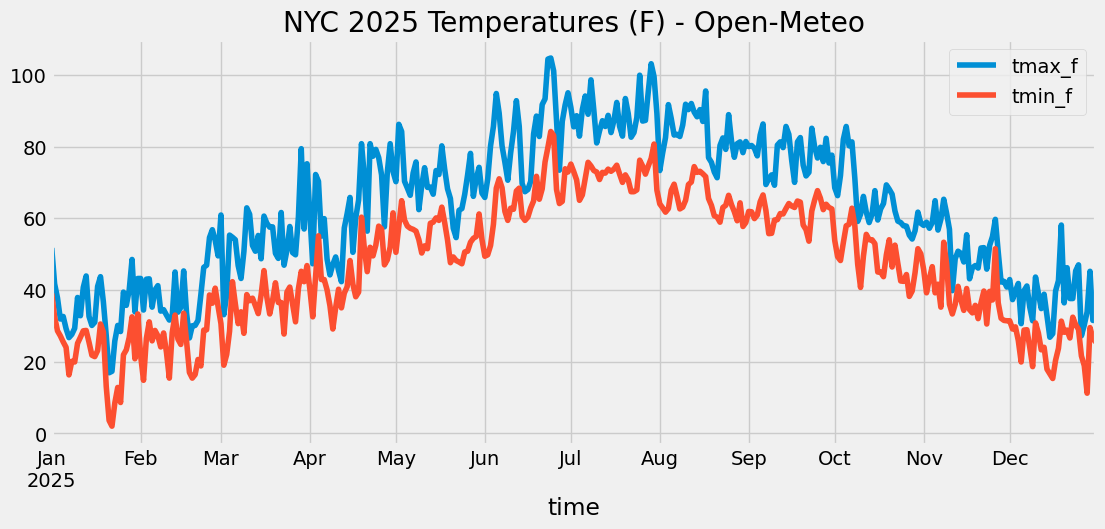

In [4]:
def fetch_historical_weather(city_name, start_date, end_date):
    """
    Fetches historical daily weather from Open-Meteo (No API key needed).
    """
    cities = {
        'NYC': {'lat': 40.71, 'lon': -74.01},
        'Chicago': {'lat': 41.87, 'lon': -87.62},
        'Miami': {'lat': 25.76, 'lon': -80.19},
        'Austin': {'lat': 30.26, 'lon': -97.74},
        'Denver': {'lat': 39.73, 'lon': -104.99},
    }
    
    city = cities.get(city_name)
    if not city:
        raise ValueError(f"City {city_name} not found.")

    url = (
        f"https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={city['lat']}&longitude={city['lon']}&"
        f"start_date={start_date}&end_date={end_date}&"
        f"daily=temperature_2m_max,temperature_2m_min&"
        f"temperature_unit=fahrenheit&timezone=auto"
    )

    response = requests.get(url)
    data = response.json()
    
    # Parse results into DataFrame
    df = pd.DataFrame(data['daily'])
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df.rename(columns={'temperature_2m_max': 'tmax_f', 'temperature_2m_min': 'tmin_f'}, inplace=True)
    
    print(f"✅ Successfully fetched {len(df)} days for {city_name} via Open-Meteo.")
    return df

# Fetch 2025 data (Adjust dates as needed)
weather_df = fetch_historical_weather('NYC', '2025-01-01', '2025-12-31')
weather_df[['tmax_f', 'tmin_f']].plot(figsize=(12, 5), title="NYC 2025 Temperatures (F) - Open-Meteo")


In [5]:
# Cell 3: Kalshi Market Simulator (Synthetic Market Maker)
"""
Since historical Kalshi book data is proprietary, we simulate the 'Market Price' (Implied Probability).
Market Price = Real Outcome Probability + Synthetic Noise.
"""

def simulate_kalshi_market(ground_truth_temp, strike_temp, noise_level=0.15):
    """
    Simulates a Kalshi 'High Temp > Strike' market.
    - Outcome: 1 if ground_truth > strike, else 0
    - Market Price: A probability (0.0 to 1.0) with noise representing market inefficiency.
    """
    # Realized outcome
    outcome = (ground_truth_temp > strike_temp).astype(int)
    
    # Synthetic Market Price (implied probability)
    # We assume the market is loosely right, but has errors (noise)
    # If ground truth is 85 and strike is 80, market should be high (~0.8)
    # Distance to strike mapped to a sigmoid probability
    distance = ground_truth_temp - strike_temp
    base_prob = 1 / (1 + np.exp(-0.5 * distance))
    
    # Add noise to simulate trading opportunities
    market_price = base_prob + np.random.normal(0, noise_level, len(base_prob))
    market_price = np.clip(market_price, 0.05, 0.95) # Markets never stay at 0 or 100 before settlement
    
    return market_price, outcome

strike = 65
market_price, settlements = simulate_kalshi_market(weather_df['tmax_f'], strike)
weather_df['Market_Price'] = market_price
weather_df['Settlement'] = settlements
weather_df['Strike'] = strike

In [6]:
# Cell 4: Weather Backtest Strategy (Model Decision)
"""
Strategy Logic:
If OUR Model Probability (calculated here as a 'perfect' view with less noise) 
is significantly higher than Market Price, BUY YES.
"""

# Simulating 'Our Model' which is smarter than the market (less noise)
our_model_prob, _ = simulate_kalshi_market(weather_df['tmax_f'], strike, noise_level=0.02)
weather_df['Model_Prob'] = our_model_prob

# Calculate Edge (Our Prob - Market Price)
weather_df['Edge'] = weather_df['Model_Prob'] - weather_df['Market_Price']

"""
Execution Rule:
- BUY YES if Edge > 0.10 (Market is underpricing the outcome)
- BUY NO if Edge < -0.10 (Market is overpricing the outcome)
"""
weather_df['Signal'] = 0
weather_df.loc[weather_df['Edge'] > 0.10, 'Signal'] = 1   # Long Yes
weather_df.loc[weather_df['Edge'] < -0.10, 'Signal'] = -1  # Long No (Shorting Yes)

print(f"Total Trades: {(weather_df['Signal'] != 0).sum()}")

Total Trades: 59


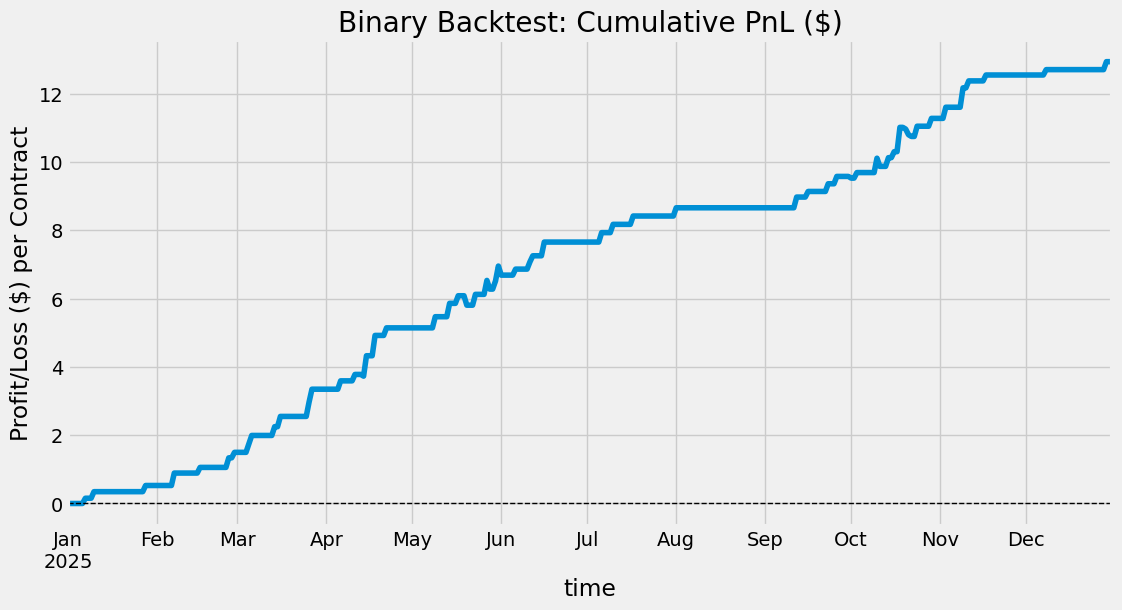

Final PnL: $12.93 per contract
Strategy Win Rate: 84.7%


In [7]:
# Cell 5: VectorBT Binary Analysis
"""
Binary PnL Calculation:
Profit = (Outcome * $1.00) - Entry Price
Essentially: You pay 60¢ to win $1.00 (40¢ profit) or 0¢ ($60¢ loss).
"""

def calculate_binary_pnl(signal, settlement, price):
    if signal == 1: # Buy Yes
        return settlement - price
    elif signal == -1: # Buy No
        return (1 - settlement) - (1 - price)
    return 0

pnl_vector = weather_df.apply(lambda x: calculate_binary_pnl(x['Signal'], x['Settlement'], x['Market_Price']), axis=1)
cumulative_pnl = pnl_vector.cumsum()

# Plotting Equity Curve
plt.figure(figsize=(12, 6))
cumulative_pnl.plot(title="Binary Backtest: Cumulative PnL ($)")
plt.ylabel("Profit/Loss ($) per Contract")
plt.axhline(0, color='black', lw=1, ls='--')
plt.show()

win_rate = (pnl_vector[pnl_vector != 0] > 0).mean()
print(f"Final PnL: ${cumulative_pnl.iloc[-1]:.2f} per contract")
print(f"Strategy Win Rate: {win_rate*100:.1f}%")